# MRS Bulletin Figures
> Georgios Varnavides, Willem de Kleijne, Stephanie Ribet

## Phase Contrast Imaging

In [1]:
import numpy as np
import abtem
import ase

In [2]:
# Geometry
cellDim = np.array([140., 140., 140.])
shift2 = np.array([ 15, cellDim[1]/2-15, cellDim[2]/2-15])
shift3 = np.array([-15, -cellDim[1]/2+15, -cellDim[2]/2+15])

# CNTs
atoms01 = ase.build.nanotube(10, 5, length=500, bond=1.42)
atoms02 = ase.build.nanotube(6, 8, length=100, bond=1.42)
atoms02b = ase.build.nanotube(9, 12, length=100, bond=1.42)
atoms03 = ase.build.nanotube(5, 13, length=100, bond=1.42)

for atoms in [atoms01,atoms02,atoms02b,atoms03]:
    atoms.cell = cellDim
    atoms.center()
    atoms.rotate(90,'y',center="COM")

# diagonal CNT
atoms01.rotate(-45,'y',center="COM")
atoms01.rotate(45,'z',center="COM")

# double-walled CNT
atoms02.translate(shift2)
atoms02b.translate(shift2)

# single-walled CNT
atoms03.translate(shift3)

for atoms in [atoms01,atoms02,atoms02b,atoms03]:
    del atoms[
            (atoms.positions[:,0] < 0) |
            (atoms.positions[:,1] < 0) |
            # (atoms.positions[:,2] < 0) |
            (atoms.positions[:,0] > cellDim[0]) |
            (atoms.positions[:,1] > cellDim[1]) #|
            # (atoms.positions[:,2] > cellDim[2])
    ]

atoms = atoms01 + atoms02 + atoms02b + atoms03

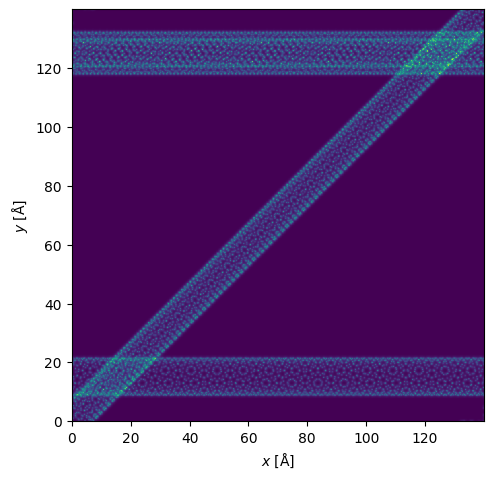

In [3]:
potential = abtem.Potential(
    atoms,
    gpts=(1024,1024),
    # sampling=0.1,
).build(
    lazy=False
)

potential.show()

In [4]:
energy = 80e3
dose = 5e2
defocus = 500
seed = 2025

planewave = abtem.PlaneWave(
    energy=energy
).match_grid(
    potential
)

exit_wave = planewave.multislice(
    potential,
    lazy=False
)

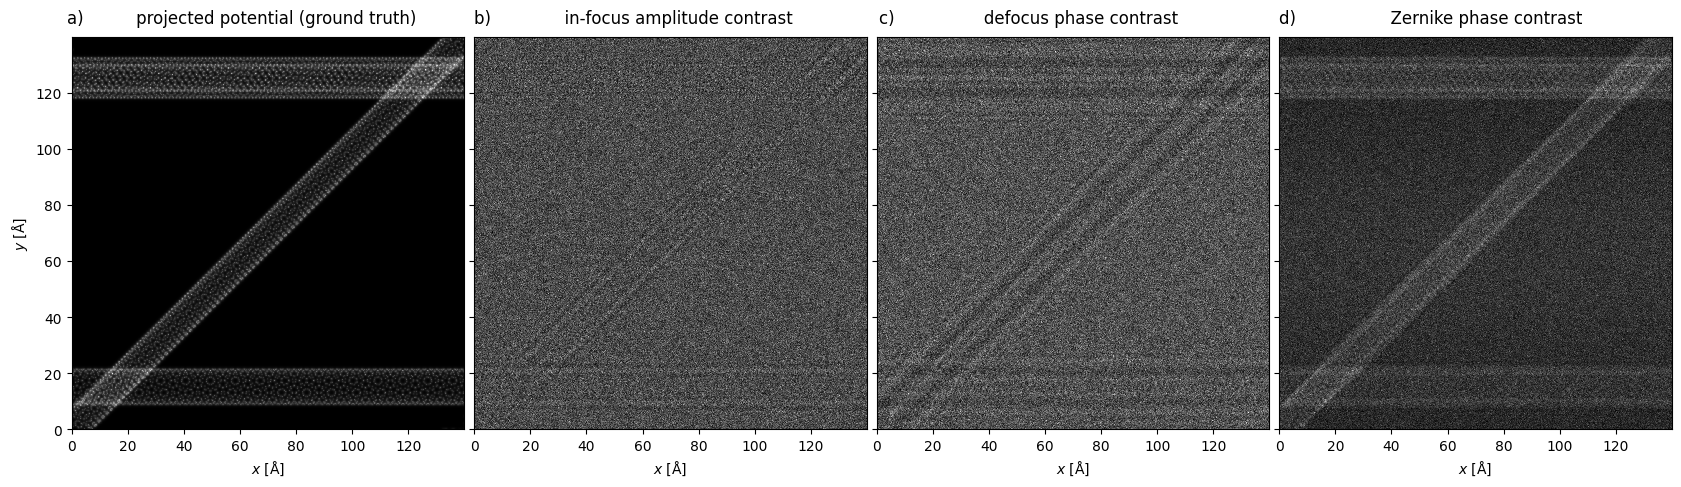

In [5]:
zernike_kernel = abtem.transfer.Zernike(
    semiangle_cutoff = np.inf,
    center_hole_cutoff = planewave.angular_sampling[0],
    phase_shift=-np.pi/2,
    energy=energy,
).match_grid(
    potential
)

zernike = exit_wave.copy().apply_ctf(zernike_kernel).intensity().poisson_noise(dose,seed=seed)
defocused = exit_wave.copy().apply_ctf(defocus=defocus).intensity().poisson_noise(dose,seed=seed)
hrtem = exit_wave.copy().intensity().poisson_noise(dose,seed=seed)

stack = abtem.stack(
    (
        potential.project(),
        hrtem,
        defocused,
        zernike
    ),
    (
        f"a) {'projected potential (ground truth)':^53}",
        f"b) {'in-focus amplitude contrast':^54}",
        f"c) {'defocus phase contrast':^55}",
        f"d) {'Zernike phase contrast':^56}"
    )
)

viz = stack.show(explode=True,figsize=(18,5),cmap='gray')
viz.axes.fig.savefig("phase_contrast_imaging_CNTs.png",bbox_inches='tight')
viz.axes.fig.savefig("phase_contrast_imaging_CNTs.pdf",bbox_inches='tight')